In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [68]:
import os
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)

print("Total files are:",len(total_files))

# we would check now to see if no. of .wav and .txt files are matching or not

wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

print("Total .wav files:",len(wav_files))  #920
print("Total .txt files:",len(txt_files))  #922

#so mismatch is there, we need to use only those which have both .wav and .txt

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt","") for f in txt_files])

common_files = list(wav_set.intersection(txt_set))

print("Usable files:", len(common_files))

missing_txt = wav_set - txt_set
missing_wav = txt_set - wav_set

print("Total wav files without txt files:",missing_txt)
print("Total txt files without wav files:",missing_wav)

Total files are: 1843
Total .wav files: 920
Total .txt files: 922
Usable files: 920
Total wav files without txt files: set()
Total txt files without wav files: {'filename_format', 'filename_differences'}


In [70]:
train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files  = train_test_split(train_files, test_size=0.2, random_state=42)

In [71]:
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def time_shift(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def time_stretch(signal, rate=0.9):
    return librosa.effects.time_stretch(signal, rate)

def pitch_shift(signal, sr=16000, n_steps=1):
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)

In [72]:
def augment_signal(signal, sr=16000):
    augmented = []

    # original
    augmented.append(signal)

    # noise
    augmented.append(add_noise(signal))

    # shift
    augmented.append(time_shift(signal))

    # stretch (safe range)
    try:
        augmented.append(time_stretch(signal, rate=np.random.uniform(0.9, 1.1)))
    except:
        pass

    # pitch (very small)
    try:
        augmented.append(pitch_shift(signal, sr, n_steps=np.random.uniform(-1,1)))
    except:
        pass

    return augmented

In [73]:
def build_segments(file_list,augment=False):
    segments = []
    labels = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()

                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]

                if len(segment) < 1000:
                    continue

                # 4-class labeling
                if crackle==0 and wheeze==0:
                    label=0
                elif crackle==1 and wheeze==0:
                    label=1
                elif crackle==0 and wheeze==1:
                    label=2
                else:
                    label=3
                if augment:
                    aug_list = augment_signal(segment, sr)
                    for aug in aug_list:
                        segments.append(aug)
                        labels.append(label)
                else:
                    segments.append(segment)
                    labels.append(label)

    return segments, labels

In [74]:
X_train, y_train = build_segments(train_files)
X_val, y_val     = build_segments(val_files)
X_test, y_test   = build_segments(test_files)

In [75]:
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

In [76]:
def extract_embedding(signal):
    signal = signal.astype(np.float32)

    _, embeddings, _ = yamnet(signal)
    emb = embeddings.numpy()

    mean = np.mean(emb, axis=0)
    std  = np.std(emb, axis=0)
    max_ = np.max(emb, axis=0)
    min_ = np.min(emb, axis=0)

    
    median = np.median(emb, axis=0)
    q25 = np.percentile(emb, 25, axis=0)
    q75 = np.percentile(emb, 75, axis=0)

    return np.concatenate([mean, std, max_, min_, median, q25, q75])    
    
def create_embedding_dataset(X, y):
    X_emb = []
    y_clean = []

    for seg, label in zip(X, y):
        try:
            emb = extract_embedding(seg)
            X_emb.append(emb)
            y_clean.append(label)
        except:
            continue

    return np.array(X_emb), np.array(y_clean)

In [77]:
X_train_emb, y_train = create_embedding_dataset(X_train, y_train)
X_val_emb, y_val     = create_embedding_dataset(X_val, y_val)
X_test_emb, y_test   = create_embedding_dataset(X_test, y_test)

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(2048, activation='relu', input_shape=(7168,)),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8,activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 2048)           │    14,682,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,881,756 (60.58 MB)

 Trainable params: 15,881,756 (60.58 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model.compile(
    optimizer= Adam(learning_rate=1e-4),
    loss= 'sparse_categorical_crossentropy' ,
    metrics=['accuracy']
)

In [80]:
history = model.fit(
    X_train_emb, y_train,
    validation_data=(X_val_emb, y_val),
    epochs=100,
    batch_size=8
)

Epoch 1/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4643 - loss: 1.3655 - val_accuracy: 0.5348 - val_loss: 1.2755
Epoch 2/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4893 - loss: 1.2858 - val_accuracy: 0.5212 - val_loss: 1.2181
Epoch 3/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4724 - loss: 1.2760 - val_accuracy: 0.5348 - val_loss: 1.2494
Epoch 4/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5237 - loss: 1.2433 - val_accuracy: 0.5348 - val_loss: 1.1594
Epoch 5/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5084 - loss: 1.1932 - val_accuracy: 0.5348 - val_loss: 1.1695
Epoch 6/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5194 - loss: 1.1757 - val_accuracy: 0.5348 - val_loss: 1.1565
Epoch 7/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5183 - loss: 1.1453 - val_accuracy: 0.5348 - val_loss: 1.1229
Epoch 8/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5370 - loss: 1.1386 - val_ac

In [81]:
def build_segments_with_ids(file_list):
    segments = []
    labels = []
    file_ids = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()

                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]

                if len(segment) < 1000:
                    continue

                if crackle==0 and wheeze==0:
                    label=0
                elif crackle==1 and wheeze==0:
                    label=1
                elif crackle==0 and wheeze==1:
                    label=2
                else:
                    label=3

                segments.append(segment)
                labels.append(label)
                file_ids.append(file)

    return segments, labels, file_ids

In [82]:
X_test, y_test, test_ids = build_segments_with_ids(test_files)

In [83]:
X_test_emb, y_test = create_embedding_dataset(X_test, y_test)

y_pred_prob = model.predict(X_test_emb)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [84]:
from collections import defaultdict
import numpy as np

file_preds = defaultdict(list)
file_true  = {}

for prob, label, fid in zip(y_pred_prob, y_test, test_ids):
    file_preds[fid].append(prob)
    file_true[fid] = label  # last label works since same file

In [85]:
y_true_file = []
y_pred_file = []

for fid in file_preds:
    probs = np.array(file_preds[fid])

    conf = np.max(probs, axis=1)

    k = max(1, len(probs)//3)
    top_idx = np.argsort(conf)[-k:]
    
    top_probs = probs[top_idx]
    top_conf  = conf[top_idx]
    
    weights = top_conf / np.sum(top_conf)
    
    final_prob = np.sum(top_probs * weights[:, None], axis=0)
    pred = np.argmax(final_prob)
    
    y_pred_file.append(pred)
    y_true_file.append(file_true[fid])

In [86]:
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_true_file, y_pred_file))
print("Macro F1:", f1_score(y_true_file, y_pred_file, average='macro'))
print("Weighted F1:", f1_score(y_true_file, y_pred_file, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_true_file, y_pred_file))


Accuracy: 0.657608695652174
Macro F1: 0.4469179706021811
Weighted F1: 0.6209078071206217

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.84      0.77       101
           1       0.56      0.62      0.59        45
           2       0.62      0.33      0.43        24
           3       0.00      0.00      0.00        14

    accuracy                           0.66       184
   macro avg       0.47      0.45      0.45       184
weighted avg       0.60      0.66      0.62       184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


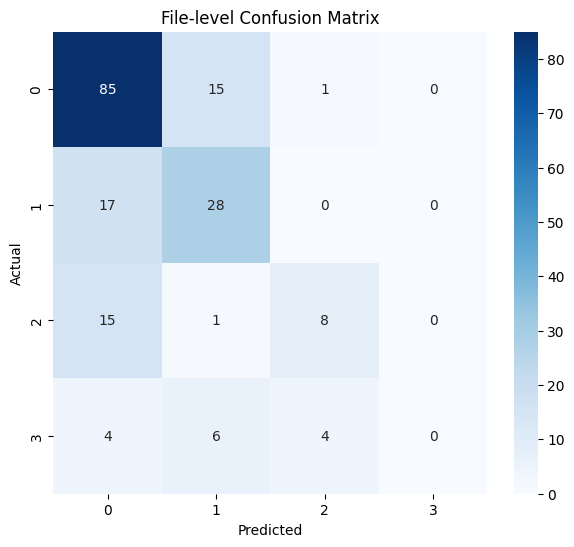

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_file, y_pred_file)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("File-level Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [88]:
model.save("/kaggle/working/Aero_yamnet.keras")

In [89]:
import json

config = {
    "sr": 16000,
    "feature_dim": X_train_emb.shape[1],  # should be 7168 now
    "num_classes": 4,
    "aggregation": "topk_weighted",       # what you used
}

with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f)

In [90]:
import numpy as np

mean = np.mean(X_train_emb, axis=0)
std  = np.std(X_train_emb, axis=0) + 1e-8

np.save("/kaggle/working/mean.npy", mean)
np.save("/kaggle/working/std.npy", std)

In [91]:
import zipfile

zip_path = "/kaggle/working/yamnet_model_bundle.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    z.write("/kaggle/working/Aero_yamnet.keras", arcname="model.keras")
    z.write("/kaggle/working/mean.npy", arcname="mean.npy")
    z.write("/kaggle/working/std.npy", arcname="std.npy")
    z.write("/kaggle/working/config.json", arcname="config.json")